# ETL — Modelado Star Schema | Teatro Musical España (2010–2026)

## Punto de entrada
Este notebook toma `data_raw/maestro_musicales.csv` — el dataset maestro curado manualmente
a partir de fuentes públicas del sector (webs de productoras, teatros, carteleras históricas
y comunicación institucional) — y lo transforma en un modelo estrella listo para Power BI.

## Output generado en `data_processed/`
| Archivo | Descripción |
|---|---|
| `fact_producciones.csv` | Tabla de hechos (72 producciones) |
| `dim_obra.csv` | Dimensión obra (género, origen, duración) |
| `dim_teatro.csv` | Dimensión teatro (nombre, ciudad) |
| `dim_anio.csv` | Dimensión año |
| `maestro_musicales_final.csv` | Dataset maestro limpio completo |

## Cómo ejecutar
1. Ejecutar todas las celdas en orden (`Run All`)
2. Abrir Power BI y hacer clic en **Actualizar**

In [ ]:
import pandas as pd
import numpy as np
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

## 1. Carga de datos

In [ ]:
# 1) CARGA
# =========================
df_maestro = pd.read_csv("../data_raw/maestro_musicales.csv")


In [ ]:
print("SHAPE inicial:", df_maestro.shape)
display(df_maestro.head())

SHAPE inicial: (72, 10)


,obra,productora,anio_inicio,anio_fin,teatro,gira,activa,duracion,genero,origen
0,"101 Dálmatas, el musical",Teatropolis (Gran Teatro CaixaBank Príncipe Pío),2023,NaN,Gran Teatro CaixaBank Príncipe Pío,No,True,90,Comedia,Creacion Propia
1,Aladdín,Stage Entertainment,2023,2025.0,Teatro Coliseum,No,False,145,Familiar,Franquicia
2,Anastasia,Stage Entertainment,2018,2020.0,Teatro Coliseum,No,False,95,Familiar,Franquicia
3,Annie,Theatre Properties,2010,2011.0,Teatro Nuevo Alcalá,No,False,120,Familiar,Franquicia
4,Avenue Q,SMedia,2010,2011.0,Teatro Nuevo Apolo,No,False,135,Comedia,Franquicia


## 2. Limpieza y normalización

In [ ]:
# 2) LIMPIEZA Y ESTANDARIZACIÓN
# =========================

# 2.1 Tipos numéricos
for c in ["anio_inicio", "anio_fin", "duracion"]:
    if c in df_maestro.columns:
        df_maestro[c] = pd.to_numeric(df_maestro[c], errors="coerce").astype("Int64")

# 2.2 Limpieza de texto base
for c in ["obra", "productora", "teatro", "genero", "origen"]:
    if c in df_maestro.columns:
        df_maestro[c] = df_maestro[c].astype("string").str.strip()

# 2.3 Normalización de texto
if "genero" in df_maestro.columns:
    df_maestro["genero"] = df_maestro["genero"].str.title()

if "origen" in df_maestro.columns:
    df_maestro["origen"] = df_maestro["origen"].str.title().replace({
        "Creacion Propia": "Creación Propia",
        "Creación propia": "Creación Propia",
        "Franquicia ": "Franquicia"
    })

# 2.4 Booleanos
for col in ["gira", "activa"]:
    if col in df_maestro.columns:
        df_maestro[col] = (
            df_maestro[col]
            .astype(str)
            .str.strip()
            .str.lower()
            .map({
                "true": True, "false": False,
                "sí": True, "si": True, "no": False,
                "1": True, "0": False
            })
            .astype("boolean")
        )

# 2.5 Eliminar duplicados exactos
df_maestro = df_maestro.drop_duplicates()

# =========================
# 3) DEFINIR GRANO Y CREAR ID
# Grano final: obra + productora + anio_inicio + teatro
# =========================
clave_negocio = ["obra", "productora", "anio_inicio", "teatro"]

df_maestro["id_produccion"] = (
    df_maestro["obra"].fillna("").str.upper() + "_" +
    df_maestro["productora"].fillna("").str.upper() + "_" +
    df_maestro["anio_inicio"].astype("string").fillna("") + "_" +
    df_maestro["teatro"].fillna("").str.upper()
)

# =========================
# 4) VALIDACIÓN DEL MAESTRO FINAL EN MEMORIA
# =========================
print("\nSHAPE tras limpieza:", df_maestro.shape)

print("\nINFO DEL DATASET")
df_maestro.info()

print("\nNULOS POR COLUMNA")
nulos_abs = df_maestro.isna().sum()
nulos_pct = (df_maestro.isna().mean() * 100).round(1)
df_nulos = pd.DataFrame({
    "nulos_abs": nulos_abs,
    "nulos_pct": nulos_pct
}).sort_values("nulos_abs", ascending=False)
display(df_nulos)

print("\nDUPLICADOS SEGÚN CLAVE DE NEGOCIO")
duplicados = df_maestro.duplicated(subset=clave_negocio, keep=False)
print("Filas duplicadas:", duplicados.sum())

if duplicados.sum() > 0:
    display(
        df_maestro.loc[duplicados, clave_negocio + ["id_produccion"]]
        .sort_values(clave_negocio)
    )

print("\nVALORES ÚNCOS DE TEATRO")
if "teatro" in df_maestro.columns:
    print("Nulos en teatro:", df_maestro["teatro"].isna().sum())
    display(pd.DataFrame(sorted(df_maestro["teatro"].dropna().unique()), columns=["teatro"]))

print("\nDESCRIBE NUMÉRICO")
display(df_maestro.describe(include=[np.number]))



SHAPE tras limpieza: (72, 11)

INFO DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   obra           72 non-null     string 
 1   productora     72 non-null     string 
 2   anio_inicio    72 non-null     Int64  
 3   anio_fin       58 non-null     Int64  
 4   teatro         72 non-null     string 
 5   gira           72 non-null     boolean
 6   activa         72 non-null     boolean
 7   duracion       72 non-null     Int64  
 8   genero         72 non-null     string 
 9   origen         72 non-null     string 
 10  id_produccion  72 non-null     string 
dtypes: Int64(3), boolean(2), string(6)
memory usage: 5.7 KB

NULOS POR COLUMNA


,nulos_abs,nulos_pct
anio_fin,14,19.4
productora,0,0.0
obra,0,0.0
anio_inicio,0,0.0
teatro,0,0.0
gira,0,0.0
activa,0,0.0
duracion,0,0.0
genero,0,0.0
origen,0,0.0



DUPLICADOS SEGÚN CLAVE DE NEGOCIO
Filas duplicadas: 0

VALORES ÚNCOS DE TEATRO
Nulos en teatro: 0


,teatro
0,Almería Teatre
1,Auditorio de Tenerife
2,Espacio Delicias
3,Espacio Ibercaja Delicias
4,Gran Teatro CaixaBank Príncipe Pío
5,Ifema Madrid Live
6,Las Arenas
7,Teatre Apolo
8,Teatre Poliorama
9,Teatre Victòria



DESCRIBE NUMÉRICO


,anio_inicio,anio_fin,duracion
count,72.0,58.0,72.0
mean,2018.986111,2020.155172,138.902778
std,4.951861,4.712066,26.137858
min,2010.0,2011.0,70.0
25%,2014.75,2015.25,127.5
50%,2021.0,2023.0,150.0
75%,2023.0,2024.0,151.25
max,2025.0,2025.0,180.0


In [ ]:
# 5) CAMPO AUXILIAR SOLO PARA CÁLCULOS
# =========================
max_year_in_data = (
    int(df_maestro["anio_fin"].max(skipna=True))
    if df_maestro["anio_fin"].notna().any()
    else pd.Timestamp.today().year
)

df_maestro["anio_fin_filled"] = df_maestro["anio_fin"].fillna(max_year_in_data)

# =========================
# 6) FOTO EJECUTIVA
# =========================
print("\nFOTO EJECUTIVA DEL DATASET")
print("Total de producciones:", df_maestro.shape[0])
print("Total de obras únicas:", df_maestro["obra"].nunique())
print(
    "Rango temporal:",
    f"{int(df_maestro['anio_inicio'].min())} - {int(df_maestro['anio_fin'].max())}"
    if df_maestro["anio_fin"].notna().any()
    else f"{int(df_maestro['anio_inicio'].min())} - Actualidad"
)



FOTO EJECUTIVA DEL DATASET
Total de producciones: 72
Total de obras únicas: 67
Rango temporal: 2010 - 2025


In [ ]:
# --- Años en cartel (métrica analítica) ---
# df_maestro["anios_en_cartel"] = (
#     df_maestro["anio_fin_filled"] - df_maestro["anio_inicio"] + 1
# )
#
# df_maestro.loc[
#     df_maestro["anios_en_cartel"] <= 0,
#     "anios_en_cartel"
# ] = pd.NA


## 3. Construcción del modelo estrella

In [ ]:
# MODELO ESTRELLA FINAL
# =========================

# DIM_OBRA
dim_obra = (
    df_maestro[["obra", "genero", "origen", "duracion"]]
    .drop_duplicates()
    .reset_index(drop=True)
)
dim_obra.insert(0, "id_obra", range(1, len(dim_obra) + 1))

# DIM_TEATRO
dim_teatro = (
    df_maestro[["teatro"]]
    .drop_duplicates()
    .reset_index(drop=True)
)
dim_teatro.insert(0, "id_teatro", range(1, len(dim_teatro) + 1))

ciudades_teatro = {
    'Gran Teatro CaixaBank Príncipe Pío': 'Madrid',
    'Teatro Coliseum': 'Madrid',
    'Teatro Nuevo Alcalá': 'Madrid',
    'Teatro Nuevo Apolo': 'Madrid',
    'Teatro Albéniz': 'Madrid',
    'Teatro Tívoli': 'Barcelona',
    'Espacio Ibercaja Delicias': 'Zaragoza',
    'Teatro Marquina': 'Madrid',
    'Teatro Del Soho': 'Málaga',
    'Teatre Apolo': 'Barcelona',
    'Teatro EDP Gran Vía': 'Madrid',
    'Teatro Lope de Vega': 'Sevilla',
    'Teatro Principal de Zaragoza': 'Zaragoza',
    'Teatro Pavón': 'Madrid',
    'Teatros del Canal': 'Madrid',
    'Teatro Español': 'Madrid',
    'Veranos de la Villa': 'Madrid',
    'Teatro La Latina': 'Madrid',
    'Las Arenas': 'Barcelona',
    'Teatro Calderón': 'Madrid',
    'Espacio Delicias': 'Zaragoza',
    'Teatro Rialto': 'Madrid',
    'Teatre Poliorama': 'Barcelona',
    'Teatro Lara': 'Madrid',
    'Ifema Madrid Live': 'Madrid',
    'Teatre Victòria': 'Barcelona',
    'Auditorio de Tenerife': 'Tenerife',
    'Almería Teatre': 'Almería'
}
dim_teatro["ciudad"] = dim_teatro["teatro"].map(ciudades_teatro)

# DIM_ANIO — surrogate key estable para el modelo estrella
dim_anio = (
    df_maestro[["anio_inicio"]]
    .drop_duplicates()
    .sort_values("anio_inicio")
    .rename(columns={"anio_inicio": "anio"})
    .reset_index(drop=True)
)
dim_anio.insert(0, "id_anio", range(1, len(dim_anio) + 1))

# FACT_PRODUCCIONES
fact_producciones = df_maestro[
    ["id_produccion", "obra", "productora", "anio_inicio", "anio_fin", "teatro", "gira", "activa"]
].copy()

fact_producciones = fact_producciones.merge(dim_obra[["obra", "id_obra"]], on="obra", how="left")
fact_producciones = fact_producciones.merge(dim_teatro[["teatro", "id_teatro"]], on="teatro", how="left")

display(fact_producciones.head())


,id_produccion,obra,productora,anio_inicio,anio_fin,teatro,gira,activa,id_obra,id_teatro
0,"101 DÁLMATAS, EL MUSICAL_TEATROPOLIS (GRAN TEA...","101 Dálmatas, el musical",Teatropolis (Gran Teatro CaixaBank Príncipe Pío),2023,<NA>,Gran Teatro CaixaBank Príncipe Pío,False,True,1,1
1,ALADDÍN_STAGE ENTERTAINMENT_2023_TEATRO COLISEUM,Aladdín,Stage Entertainment,2023,2025,Teatro Coliseum,False,False,2,2
2,ANASTASIA_STAGE ENTERTAINMENT_2018_TEATRO COLI...,Anastasia,Stage Entertainment,2018,2020,Teatro Coliseum,False,False,3,2
3,ANNIE_THEATRE PROPERTIES_2010_TEATRO NUEVO ALCALÁ,Annie,Theatre Properties,2010,2011,Teatro Nuevo Alcalá,False,False,4,3
4,AVENUE Q_SMEDIA_2010_TEATRO NUEVO APOLO,Avenue Q,SMedia,2010,2011,Teatro Nuevo Apolo,False,False,5,4


In [ ]:
print("FACT shape:", fact_producciones.shape)
print("DIM_OBRA shape:", dim_obra.shape)
print("DIM_TEATRO shape:", dim_teatro.shape)
print("DIM_ANIO shape:", dim_anio.shape)

print("\nNULOS FACT")
print(fact_producciones.isna().sum())

print("\nNULOS DIM_OBRA")
print(dim_obra.isna().sum())

print("\nNULOS DIM_TEATRO")
print(dim_teatro.isna().sum())

print("\nNULOS DIM_ANIO")
print(dim_anio.isna().sum())

FACT shape: (72, 10)
DIM_OBRA shape: (67, 5)
DIM_TEATRO shape: (28, 3)
DIM_ANIO shape: (15, 2)

NULOS FACT
id_produccion     0
obra              0
productora        0
anio_inicio       0
anio_fin         14
teatro            0
gira              0
activa            0
id_obra           0
id_teatro         0
dtype: int64

NULOS DIM_OBRA
id_obra     0
obra        0
genero      0
origen      0
duracion    0
dtype: int64

NULOS DIM_TEATRO
id_teatro    0
teatro       0
ciudad       0
dtype: int64

NULOS DIM_ANIO
id_anio    0
anio       0
dtype: int64


In [ ]:
fact_producciones[["id_obra","id_teatro"]].duplicated().sum()

np.int64(0)

In [ ]:
print("\nMAESTRO")
display(df_maestro.head())

print("\nFACT_PRODUCCIONES")
display(fact_producciones.head())

print("\nDIM_OBRA")
display(dim_obra.head())

print("\nDIM_TEATRO")
display(dim_teatro.head())

print("\nDIM_ANIO")
display(dim_anio.head())


MAESTRO


,obra,productora,anio_inicio,anio_fin,teatro,gira,activa,duracion,genero,origen,id_produccion,anio_fin_filled
0,"101 Dálmatas, el musical",Teatropolis (Gran Teatro CaixaBank Príncipe Pío),2023,<NA>,Gran Teatro CaixaBank Príncipe Pío,False,True,90,Comedia,Creación Propia,"101 DÁLMATAS, EL MUSICAL_TEATROPOLIS (GRAN TEA...",2025
1,Aladdín,Stage Entertainment,2023,2025,Teatro Coliseum,False,False,145,Familiar,Franquicia,ALADDÍN_STAGE ENTERTAINMENT_2023_TEATRO COLISEUM,2025
2,Anastasia,Stage Entertainment,2018,2020,Teatro Coliseum,False,False,95,Familiar,Franquicia,ANASTASIA_STAGE ENTERTAINMENT_2018_TEATRO COLI...,2020
3,Annie,Theatre Properties,2010,2011,Teatro Nuevo Alcalá,False,False,120,Familiar,Franquicia,ANNIE_THEATRE PROPERTIES_2010_TEATRO NUEVO ALCALÁ,2011
4,Avenue Q,SMedia,2010,2011,Teatro Nuevo Apolo,False,False,135,Comedia,Franquicia,AVENUE Q_SMEDIA_2010_TEATRO NUEVO APOLO,2011



FACT_PRODUCCIONES


,id_produccion,obra,productora,anio_inicio,anio_fin,teatro,gira,activa,id_obra,id_teatro
0,"101 DÁLMATAS, EL MUSICAL_TEATROPOLIS (GRAN TEA...","101 Dálmatas, el musical",Teatropolis (Gran Teatro CaixaBank Príncipe Pío),2023,<NA>,Gran Teatro CaixaBank Príncipe Pío,False,True,1,1
1,ALADDÍN_STAGE ENTERTAINMENT_2023_TEATRO COLISEUM,Aladdín,Stage Entertainment,2023,2025,Teatro Coliseum,False,False,2,2
2,ANASTASIA_STAGE ENTERTAINMENT_2018_TEATRO COLI...,Anastasia,Stage Entertainment,2018,2020,Teatro Coliseum,False,False,3,2
3,ANNIE_THEATRE PROPERTIES_2010_TEATRO NUEVO ALCALÁ,Annie,Theatre Properties,2010,2011,Teatro Nuevo Alcalá,False,False,4,3
4,AVENUE Q_SMEDIA_2010_TEATRO NUEVO APOLO,Avenue Q,SMedia,2010,2011,Teatro Nuevo Apolo,False,False,5,4



DIM_OBRA


,id_obra,obra,genero,origen,duracion
0,1,"101 Dálmatas, el musical",Comedia,Creación Propia,90
1,2,Aladdín,Familiar,Franquicia,145
2,3,Anastasia,Familiar,Franquicia,95
3,4,Annie,Familiar,Franquicia,120
4,5,Avenue Q,Comedia,Franquicia,135



DIM_TEATRO


,id_teatro,teatro,ciudad
0,1,Gran Teatro CaixaBank Príncipe Pío,Madrid
1,2,Teatro Coliseum,Madrid
2,3,Teatro Nuevo Alcalá,Madrid
3,4,Teatro Nuevo Apolo,Madrid
4,5,Teatro Albéniz,Madrid



DIM_ANIO


,id_anio,anio
0,1,2010
1,2,2011
2,3,2012
3,4,2013
4,5,2014


In [ ]:
print(fact_producciones.columns.tolist())
display(fact_producciones.head())

['id_produccion', 'obra', 'productora', 'anio_inicio', 'anio_fin', 'teatro', 'gira', 'activa', 'id_obra', 'id_teatro']


,id_produccion,obra,productora,anio_inicio,anio_fin,teatro,gira,activa,id_obra,id_teatro
0,"101 DÁLMATAS, EL MUSICAL_TEATROPOLIS (GRAN TEA...","101 Dálmatas, el musical",Teatropolis (Gran Teatro CaixaBank Príncipe Pío),2023,<NA>,Gran Teatro CaixaBank Príncipe Pío,False,True,1,1
1,ALADDÍN_STAGE ENTERTAINMENT_2023_TEATRO COLISEUM,Aladdín,Stage Entertainment,2023,2025,Teatro Coliseum,False,False,2,2
2,ANASTASIA_STAGE ENTERTAINMENT_2018_TEATRO COLI...,Anastasia,Stage Entertainment,2018,2020,Teatro Coliseum,False,False,3,2
3,ANNIE_THEATRE PROPERTIES_2010_TEATRO NUEVO ALCALÁ,Annie,Theatre Properties,2010,2011,Teatro Nuevo Alcalá,False,False,4,3
4,AVENUE Q_SMEDIA_2010_TEATRO NUEVO APOLO,Avenue Q,SMedia,2010,2011,Teatro Nuevo Apolo,False,False,5,4


In [ ]:
# 1. Confirmar que NO hay nulos en dimensiones
print("Nulos DIM_OBRA")
print(dim_obra.isna().sum())

print("\nNulos DIM_TEATRO")
print(dim_teatro.isna().sum())

print("\nNulos DIM_ANIO")
print(dim_anio.isna().sum())

Nulos DIM_OBRA
id_obra     0
obra        0
genero      0
origen      0
duracion    0
dtype: int64

Nulos DIM_TEATRO
id_teatro    0
teatro       0
ciudad       0
dtype: int64

Nulos DIM_ANIO
id_anio    0
anio       0
dtype: int64


In [ ]:
# 2. Ver si hay espacios o caracteres raros en teatros
dim_teatro["teatro_limpio"] = dim_teatro["teatro"].str.strip()

print("\nTeatros con posible problema de espacios:")
display(dim_teatro[dim_teatro["teatro"] != dim_teatro["teatro_limpio"]])


Teatros con posible problema de espacios:


,id_teatro,teatro,ciudad,teatro_limpio


In [ ]:
# 3. Confirmar que dim_anio está ordenado correctamente
print("\nDIM_ANIO ordenado:")
display(dim_anio.sort_values("anio"))


DIM_ANIO ordenado:


,id_anio,anio
0,1,2010
1,2,2011
2,3,2012
3,4,2013
4,5,2014
5,6,2015
6,7,2017
7,8,2018
8,9,2019
9,10,2020


In [ ]:
# 4. Verificar que todos los teatros del FACT existen en DIM_TEATRO
teatros_fact = set(fact_producciones["teatro"])
teatros_dim = set(dim_teatro["teatro"])

print("\nTeatros en FACT que no están en DIM:")
print(teatros_fact - teatros_dim)


Teatros en FACT que no están en DIM:
set()


## 4. Visualización exploratoria

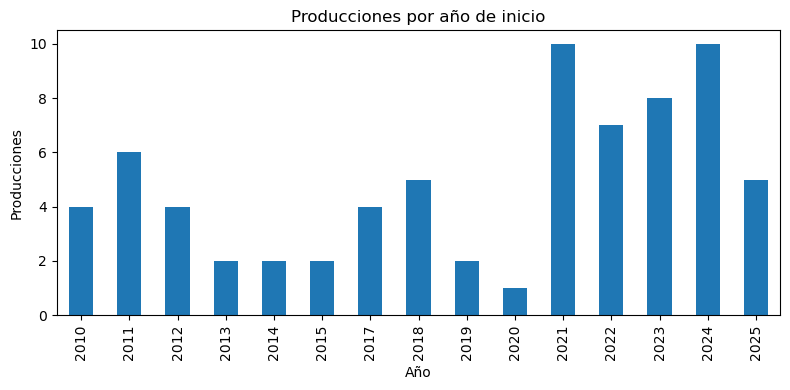

In [ ]:
# GRÁFICA 1 — PRODUCCIONES POR AÑO
# =========================
prod_anio = df_maestro["anio_inicio"].value_counts().sort_index()

plt.figure(figsize=(8,4))
prod_anio.plot(kind="bar")
plt.title("Producciones por año de inicio")
plt.xlabel("Año")
plt.ylabel("Producciones")
plt.tight_layout()
plt.show()


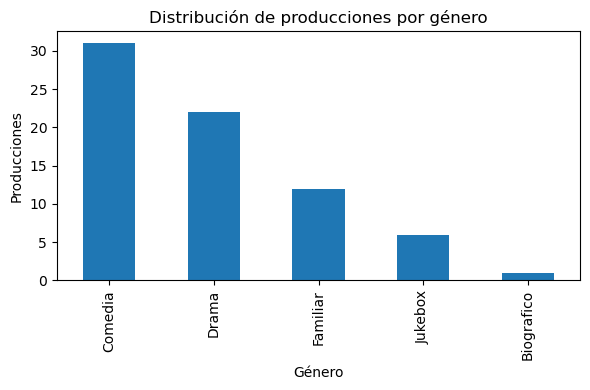

In [ ]:
# GRÁFICA 2 — DISTRIBUCIÓN DE GÉNEROS
# =========================
genero_counts = df_maestro["genero"].value_counts()

plt.figure(figsize=(6,4))
genero_counts.plot(kind="bar")
plt.title("Distribución de producciones por género")
plt.xlabel("Género")
plt.ylabel("Producciones")
plt.tight_layout()
plt.show()


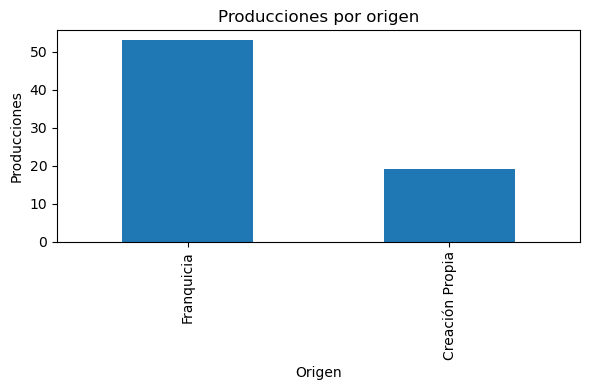

In [ ]:
# GRÁFICA 3 — ORIGEN DE LAS PRODUCCIONES
# =========================
origen_counts = df_maestro["origen"].value_counts()

plt.figure(figsize=(6,4))
origen_counts.plot(kind="bar")
plt.title("Producciones por origen")
plt.xlabel("Origen")
plt.ylabel("Producciones")
plt.tight_layout()
plt.show()


## 5. Exportación a `data_processed/`

In [ ]:
# 6) EXPORTACIÓN FINAL
# =========================
df_maestro.to_csv("../data_processed/maestro_musicales_final.csv", index=False, encoding="utf-8-sig")
fact_producciones.to_csv("../data_processed/fact_producciones.csv", index=False, encoding="utf-8-sig")
dim_obra.to_csv("../data_processed/dim_obra.csv", index=False, encoding="utf-8-sig")
dim_teatro = dim_teatro.drop(columns=["teatro_limpio"], errors="ignore")
dim_teatro.to_csv("../data_processed/dim_teatro.csv", index=False, encoding="utf-8-sig")
dim_anio.to_csv("../data_processed/dim_anio.csv", index=False, encoding="utf-8-sig")

print("Archivos exportados correctamente:\n")
print("fact_producciones:", fact_producciones.shape)
print("dim_obra:", dim_obra.shape)
print("dim_teatro:", dim_teatro.shape)
print("dim_anio:", dim_anio.shape)
print("\nTeatros sin ciudad asignada:")
print(dim_teatro[dim_teatro["ciudad"].isna()])


Archivos exportados correctamente:

fact_producciones: (72, 10)
dim_obra: (67, 5)
dim_teatro: (28, 3)
dim_anio: (15, 2)

Teatros sin ciudad asignada:
Empty DataFrame
Columns: [id_teatro, teatro, ciudad]
Index: []


## Conclusiones de preparación y modelado

- El mercado muestra una fuerte concentración en franquicias (~73 %) frente a creación propia.
- El ciclo de vida de las producciones es limitado: 14 de 72 siguen activas.
- La gira (~58 %) aparece como estrategia clave para extender la explotación territorial.
- La duración de los espectáculos está relativamente estandarizada (~138 minutos de media).
- La actividad se concentra en 28 teatros principales del ecosistema analizado.
- El dataset fue reorganizado en un modelo estrella (`fact_producciones`, `dim_obra`, `dim_teatro`, `dim_anio`) para su análisis en BI.